In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [6]:
dataset_path = "dataset"

print("Current Directory:", os.getcwd())
print("Dataset Exists:", os.path.exists(dataset_path))
print("Classes:", os.listdir(dataset_path))

Current Directory: C:\Users\thanm\OneDrive\Desktop\Textile-Waste-management-platform
Dataset Exists: True
Classes: ['Broken stitch', 'defect free', 'hole', 'horizontal', 'lines', 'Needle mark', 'Pinched fabric', 'stain', 'Vertical']


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Class Mapping:")
print(train_generator.class_indices)

Found 2457 images belonging to 9 classes.
Found 610 images belonging to 9 classes.
Class Mapping:
{'Broken stitch': 0, 'Needle mark': 1, 'Pinched fabric': 2, 'Vertical': 3, 'defect free': 4, 'hole': 5, 'horizontal': 6, 'lines': 7, 'stain': 8}


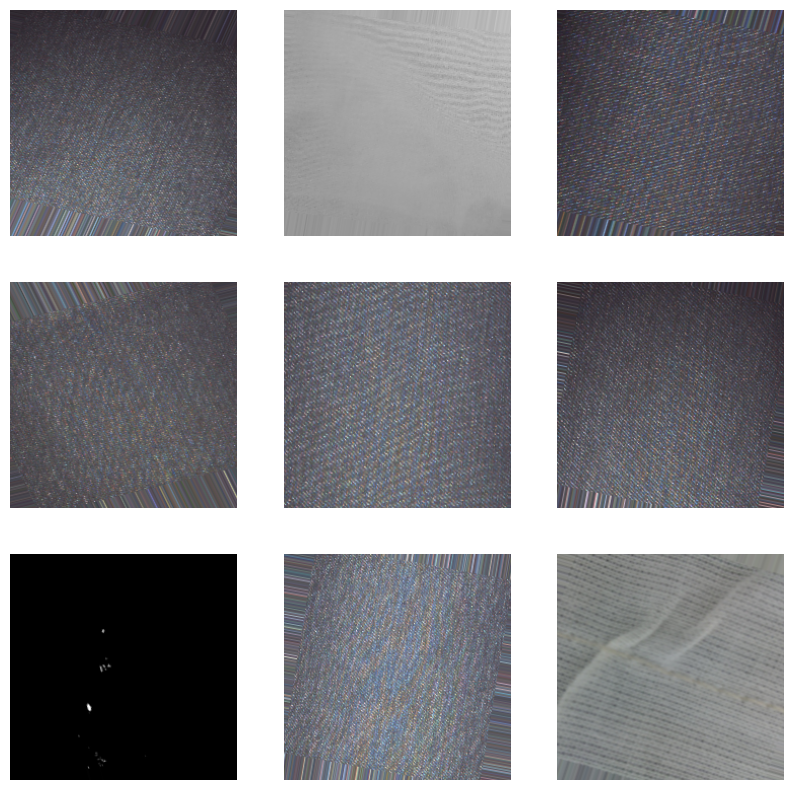

In [8]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [4]:
# Load MobileNetV2 base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(9, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

NameError: name 'MobileNetV2' is not defined

In [6]:
EPOCHS = 10

history = model.fit( 
    train_generator,
    validation_data=validation_generator, 
    epochs=EPOCHS
) 

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 513s 6s/step - accuracy: 0.5763 - loss: 1.3275 - val_accuracy: 0.7443 - val_loss: 0.9298
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 458s 6s/step - accuracy: 0.7639 - loss: 0.6685 - val_accuracy: 0.7967 - val_loss: 0.7090
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 453s 6s/step - accuracy: 0.8441 - loss: 0.4628 - val_accuracy: 0.7951 - val_loss: 0.6566
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 509s 7s/step - accuracy: 0.8588 - loss: 0.3900 - val_accuracy: 0.7639 - val_loss: 0.6359
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 648s 8s/step - accuracy: 0.8689 - loss: 0.3486 - val_accuracy: 0.8066 - val_loss: 0.5661
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 452s 6s/step - accuracy: 0.8746 - loss: 0.3200 - val_accuracy: 0.7557 - val_loss: 0.5993
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 445s 6s/step - accuracy: 0.8828 - loss: 0.3048 - val_accuracy: 0.7885 - val_loss: 0.5376
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 453s 6s/step - accuracy: 0.8917 - loss: 0.2825 - val_accuracy: 0.8016 - v

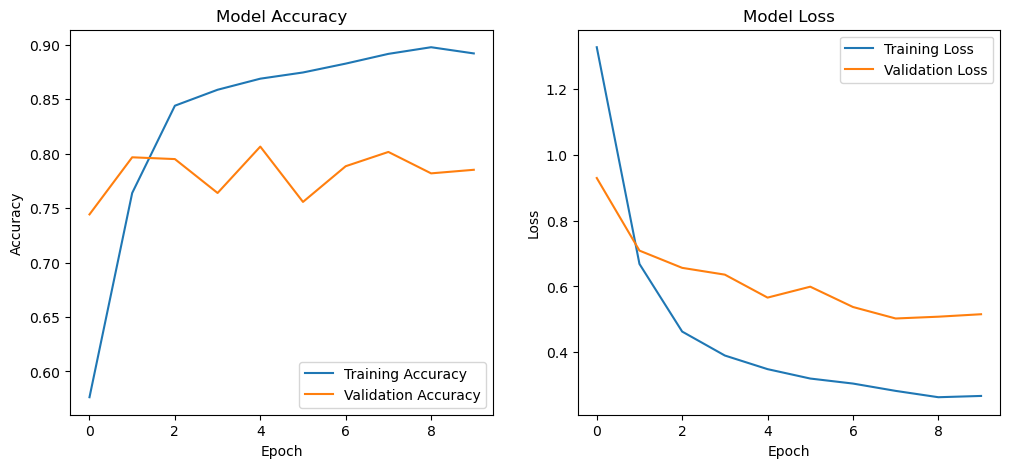

In [7]:
# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [3]:
loss, accuracy = model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

NameError: name 'model' is not defined

In [9]:
import numpy as np

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step


In [10]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

                precision    recall  f1-score   support

 Broken stitch       0.57      0.59      0.58        22
   Needle mark       0.64      0.86      0.73        21
Pinched fabric       0.93      0.67      0.78        21
      Vertical       1.00      0.45      0.62        20
   defect free       0.99      0.81      0.89       333
          hole       0.38      0.77      0.51        56
    horizontal       0.70      0.70      0.70        27
         lines       1.00      0.29      0.45        31
         stain       0.68      0.97      0.80        79

      accuracy                           0.77       610
     macro avg       0.77      0.68      0.67       610
  weighted avg       0.85      0.77      0.78       610



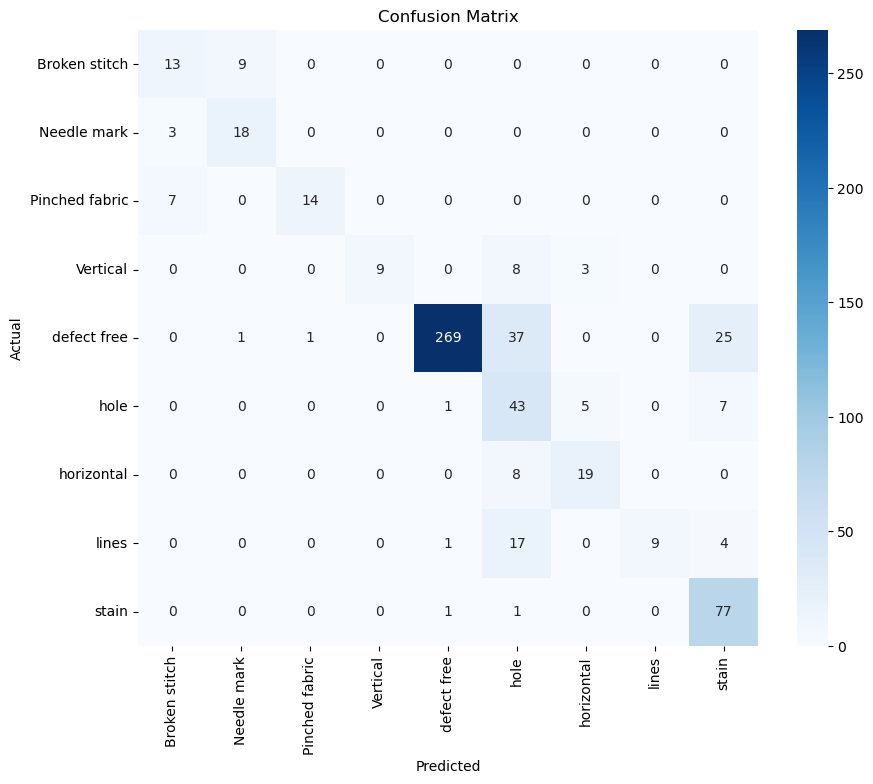

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
import os

os.makedirs("model", exist_ok=True)

model.save("model/fabric_defect_model.keras")

print("Model saved successfully!")

Model saved successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


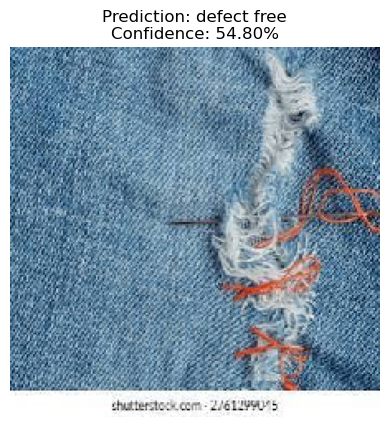

Predicted Class: defect free
Confidence: 54.804485


In [15]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "test_images/image.png"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = list(train_generator.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = r"C:\Users\thanm\OneDrive\Desktop\Textile-Waste-management-platform\dataset"

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Validation images:", validation_generator.samples)
print("Classes:", validation_generator.class_indices)

Found 610 images belonging to 9 classes.
Validation images: 610
Classes: {'Broken stitch': 0, 'Needle mark': 1, 'Pinched fabric': 2, 'Vertical': 3, 'defect free': 4, 'hole': 5, 'horizontal': 6, 'lines': 7, 'stain': 8}


In [2]:
from sklearn.metrics import classification_report
import numpy as np

loss, accuracy = model.evaluate(
    validation_generator,
    verbose=1
)

print("\n==============================")
print("MODEL EVALUATION")
print("==============================")
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

validation_generator.reset()

predictions = model.predict(
    validation_generator,
    verbose=1
)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels,
    zero_division=0
))

NameError: name 'model' is not defined

In [7]:
from backend.ai.sustainability import generate_sustainability_report

result = generate_sustainability_report(
    "Cotton",
    10,
    "Good"
)

print(result)

{'fabric_type': 'Cotton', 'quantity': 10, 'condition': 'Good', 'environmental_impact': {'co2_savings': 180.0, 'water_savings': 4200.0, 'landfill_reduction': 50.0, 'resource_recovery': 94}, 'sustainability': {'sustainability_score': 91, 'resource_recovery': 94}, 'circularity': {'score': 84.55, 'category': 'High Recovery Potential', 'material_recyclability': 94, 'condition_score': 85, 'reuse_potential': 70, 'environmental_benefit': 91, 'processing_feasibility': 70}}


In [8]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\thanm\anaconda3\python.exe
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [1]:
print(model.output_shape)


NameError: name 'model' is not defined

In [10]:
import os

model_path = "best_model.keras"

print("Model exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model size:", os.path.getsize(model_path) / (1024 * 1024), "MB")

Model exists: True
Model size: 9.467850685119629 MB


In [11]:
import tensorflow as tf

trained_model = tf.keras.models.load_model("best_model.keras")

print("Model loaded successfully!")
print("Output shape:", trained_model.output_shape)

Model loaded successfully!
Output shape: (None, 20)


In [12]:
import tensorflow as tf

new_model = tf.keras.models.load_model(
    "model/fabric_defect_model.keras"
)

print("New model loaded successfully!")
print("Output shape:", new_model.output_shape)

New model loaded successfully!
Output shape: (None, 9)


In [13]:
print(train_generator.class_indices)

{'Broken stitch': 0, 'Needle mark': 1, 'Pinched fabric': 2, 'Vertical': 3, 'defect free': 4, 'hole': 5, 'horizontal': 6, 'lines': 7, 'stain': 8}


In [14]:
import joblib
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

label_encoder.fit(
    list(train_generator.class_indices.keys())
)

print("Classes:", label_encoder.classes_)

joblib.dump(
    label_encoder,
    "backend/ai/label_encoder.pkl"
)

print("New label encoder saved successfully!")

Classes: ['Broken stitch' 'Needle mark' 'Pinched fabric' 'Vertical' 'defect free'
 'hole' 'horizontal' 'lines' 'stain']
New label encoder saved successfully!


In [15]:
import joblib
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

label_encoder.fit(
    list(train_generator.class_indices.keys())
)

print("Classes:", label_encoder.classes_)

joblib.dump(
    label_encoder,
    "backend/ai/label_encoder.pkl"
)

print("New label encoder saved successfully!")

Classes: ['Broken stitch' 'Needle mark' 'Pinched fabric' 'Vertical' 'defect free'
 'hole' 'horizontal' 'lines' 'stain']
New label encoder saved successfully!
